In [15]:
import numpy as np

def compute_weights(sample_counts, population_proportions):
    """Computes weights to adjust sample proportions to match population proportions while preserving sample size.
    
    Args:
        sample_counts (dict): Counts of each category in the sample (e.g., {'A': 10, 'B': 5}).
        population_proportions (dict): Proportions of each category in the population (e.g., {'A': 0.6, 'B': 0.4}).

    Returns:
        dict: Weights for each category.
    """
    sample_size = sum(sample_counts.values())
    
    # Convert sample counts to proportions
    sample_proportions = {k: v / sample_size for k, v in sample_counts.items()}

    # Compute raw weights
    raw_weights = {k: population_proportions[k] / sample_proportions[k] for k in sample_counts}
    
    # Normalize weights to keep total sample size unchanged
    scaling_factor = sample_size / sum(raw_weights[k] * sample_counts[k] for k in sample_counts)
    
    weights = {k: raw_weights[k] * scaling_factor for k in sample_counts}
    
    return weights

# Example usage
sample_counts = {'A': 1, 'B': 1, 'C': 1}  # Sample of 2 individuals
population_proportions = {'A': .5, 'B': 0.5, 'C':1}  # Population is 100% A

weights = compute_weights(sample_counts, population_proportions)
print(weights)  # Expected output: {'A': 2.0, 'B': 0.0}


{'A': 0.75, 'B': 0.75, 'C': 1.5}


In [16]:
import numpy as np

def compute_group_weights(sample_counts, population_proportions, groups):
    """Computes weights separately for independent groups of categories.
    
    Args:
        sample_counts (dict): Counts of each category in the sample (e.g., {'A': 10, 'B': 5, 'C': 7, 'D': 3}).
        population_proportions (dict): Proportions of each category in the population (e.g., {'A': 0.6, 'B': 0.4, 'C': 0.3, 'D': 0.7}).
        groups (list of list): Independent groups of categories (e.g., [['A', 'B'], ['C', 'D']]).

    Returns:
        dict: Weights for each category.
    """
    weights = {}

    for group in groups:
        # Get the sample size for this group
        group_sample_size = sum(sample_counts[k] for k in group)
        
        # Compute sample proportions within the group
        sample_proportions = {k: sample_counts[k] / group_sample_size for k in group}

        # Compute raw weights for the group
        raw_weights = {k: population_proportions[k] / sample_proportions[k] for k in group}

        # Normalize weights so that weighted sample count matches the original group sample size
        scaling_factor = group_sample_size / sum(raw_weights[k] * sample_counts[k] for k in group)
        group_weights = {k: raw_weights[k] * scaling_factor for k in group}

        # Store computed weights
        weights.update(group_weights)

    return weights

# Example usage
sample_counts = {'A': 1, 'B': 1, 'C': 1, 'D': 1}  # Sample of 4 individuals
population_proportions = {'A': 1.0, 'B': 0.0, 'C': 0.3, 'D': 0.7}  # Independent groups
groups = [['A', 'B'], ['C', 'D']]  # Define independent groups

weights = compute_group_weights(sample_counts, population_proportions, groups)
print(weights)


{'A': 2.0, 'B': 0.0, 'C': 0.6, 'D': 1.4}


In [42]:
import numpy as np
import pandas as pd

from io import StringIO

def compute_individual_weights(df, population_proportions):
    """Computes individual weights so that the weighted sample meets the population proportions.

    Args:
        csv_data (str): CSV string with individual-category binary matrix.
        population_proportions (dict): Target proportions for each category.

    Returns:
        dict: Individual weights.
    """
    # Convert DataFrame to matrix
    X = df.values  # Binary membership matrix (n_individuals x n_categories)
    individuals = df.index.tolist()  # Individual names
    n_individuals = X.shape[0]

    # Convert population proportions to target category counts
    pop_proportions = np.array([population_proportions[col] for col in df.columns])
    target_counts = pop_proportions * n_individuals  # Scale by sample size

    # Solve least squares to find weights
    weights, _, _, _ = np.linalg.lstsq(X, target_counts, rcond=None)

    # Normalize weights to preserve total sample size
    weights *= n_individuals / np.sum(weights)

    # Ensure non-negative weights
    weights = np.clip(weights, 0, None)

    return dict(zip(individuals, weights))

# Example data
csv_data = """
individual,A,B,C,D
a,1,0,1,0
b,0,1,0,1
c,1,0,1,0
d,0,1,0,1
"""


df = pd.read_csv(StringIO(csv_data), index_col=0)

population_proportions = {'A': 0.6, 'B': 0.4, 'C': 0.3, 'D': 0.7}

weights = compute_individual_weights(df, population_proportions)
print(weights)


{'a': 0.8999999999999999, 'b': 1.1000000000000003, 'c': 0.8999999999999998, 'd': 1.1000000000000003}


In [40]:
df.join(pd.DataFrame(weights, index=['w']).T)

,A,B,C,D,w
individual,,,,,
a,1,0,1,0,1.1
b,0,1,0,1,0.9
c,1,0,1,0,1.1
d,0,1,0,1,0.9


In [43]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from io import StringIO

def compute_individual_weights(df, population_proportions):
    """Computes individual weights so that the weighted sample meets the population proportions.

    Args:
        df (pd.DataFrame): DataFrame where rows are individuals and columns are categories (binary).
        population_proportions (dict): Target proportions for each category.

    Returns:
        dict: Individual weights.
    """
    # Convert DataFrame to matrix
    X = df.values  # Binary membership matrix (n_individuals x n_categories)
    individuals = df.index.tolist()  # Individual names
    n_individuals = X.shape[0]

    # Convert population proportions to target category counts
    pop_proportions = np.array([population_proportions[col] for col in df.columns])
    target_counts = pop_proportions * n_individuals  # Scale by sample size

    # Objective function: minimize squared error in category proportions
    def objective(w):
        return np.sum((X.T @ w - target_counts) ** 2)

    # Constraint: sum of weights must be equal to the number of individuals
    def weight_sum_constraint(w):
        return np.sum(w) - n_individuals

    # Initial guess: uniform weights
    w0 = np.ones(n_individuals)

    # Bounds: weights should be non-negative
    bounds = [(0, None) for _ in range(n_individuals)]

    # Solve optimization
    result = minimize(objective, w0, bounds=bounds, constraints={'type': 'eq', 'fun': weight_sum_constraint})

    # Get the optimal weights
    weights = result.x

    return dict(zip(individuals, weights))

# Example data
csv_data = """
individual,A,B,C,D
a,1,0,1,0
b,0,1,0,1
c,1,0,1,0
d,0,1,0,1
"""

df = pd.read_csv(StringIO(csv_data), index_col=0)

population_proportions = {'A': 0.6, 'B': 0.4, 'C': 0.3, 'D': 0.7}

weights = compute_individual_weights(df, population_proportions)
print(weights)


{'a': 0.9000000002793968, 'b': 1.0999999997206031, 'c': 0.9000000002793968, 'd': 1.0999999997206031}


In [48]:
import numpy as np
import pandas as pd
from io import StringIO

def compute_individual_weights(df, population_proportions):
    """Computes individual weights using a weighted sum approach."""
    
    # Compute the sum of occurrences for each category in the sample
    category_totals = df.sum(axis=0)  # Sum across individuals
    
    # Compute weights for each individual
    weights = df.apply(lambda row: sum(row[col] * (population_proportions[col] / category_totals[col]) 
                                       for col in df.columns if category_totals[col] > 0), axis=1)

    # Normalize weights to keep total sum of weights = number of individuals
    weights *= len(df) / weights.sum()
    
    return dict(zip(df.index, weights))

# Example data
csv_data = """
individual,A,B,C,D
a,1,0,1,0
b,0,1,0,1
c,1,0,1,0
d,0,1,0,1
"""

df = pd.read_csv(StringIO(csv_data), index_col=0)

population_proportions = {'A': 0.6, 'B': 0.4, 'C': 0.1, 'D': 0.9}

weights = compute_individual_weights(df, population_proportions)
print(weights)


{'a': 0.7, 'b': 1.3, 'c': 0.7, 'd': 1.3}


# Versão final

In [ ]:
import numpy as np
import pandas as pd
from io import StringIO

def compute_individual_weights(df, population_proportions):
    """Computes individual weights using a weighted sum approach and calculates an adjustment index."""
    
    # Compute the sum of occurrences for each category in the sample
    category_totals = df.sum(axis=0)  # Sum across individuals
    
    # Compute weights for each individual
    weights = df.apply(lambda row: sum(row[col] * (population_proportions[col] / category_totals[col]) 
                                       for col in df.columns if category_totals[col] > 0), axis=1)

    # Normalize weights to keep total sum of weights = number of individuals
    weights *= len(df) / weights.sum()

    # Compute the adjustment index
    adjustment_index = np.mean(np.abs(weights - 1))

    return dict(zip(df.index, weights)), adjustment_index

# Example data
csv_data = """
individual,A,B,C,D,E
a,1,0,1,0,1
b,0,1,0,1,0
c,1,0,1,0,0
d,0,1,0,1,0
"""

df = pd.read_csv(StringIO(csv_data), index_col=0)

population_proportions = {'A': 0.0, 'B': 1, 'C': 0.5, 'D': .5, 'E': 1}

weights, adjustment_index = compute_individual_weights(df, population_proportions)

print("Weights:", weights)
print("Adjustment Index:", adjustment_index)


Weights: {'a': 1.6666666666666665, 'b': 1.0, 'c': 0.3333333333333333, 'd': 1.0}
Adjustment Index: 0.3333333333333333


# Aplicação

In [67]:
df_parls_raw = pd.read_csv('data/df_parl_detalhes.csv', index_col=0)

In [ ]:
df_parls = df_parls_raw.copy()

df_parls = df_parls.join(pd.get_dummies(df_parls['sexo']))

df_parls.set_index('id', inplace=True)

In [92]:
population_proportions = {'F': 0.5, 'M': 0.5}


results = []
for legislatura in sorted(df_parls['ultimoStatus.idLegislatura'].unique()):
    df_parls_leg = df_parls[df_parls['ultimoStatus.idLegislatura'] == legislatura]
    weights, adjustment_index = compute_individual_weights(df_parls_leg[['F', 'M']], population_proportions)

    # print("Weights:", weights)
    print("Adjustment Index:", adjustment_index)
    results.append({
        'legislatura': legislatura,
        'adjustment_index': adjustment_index
    })




Adjustment Index: 0.9022801302931596
Adjustment Index: 0.9452054794520548
Adjustment Index: 0.822033898305085
Adjustment Index: 0.8857142857142855
Adjustment Index: 0.8046875000000002
Adjustment Index: 0.8301158301158302
Adjustment Index: 0.7908496732026145
Adjustment Index: 0.8024691358024691
Adjustment Index: 0.647457627118644
Adjustment Index: 0.6384742951907131


<Axes: xlabel='legislatura'>

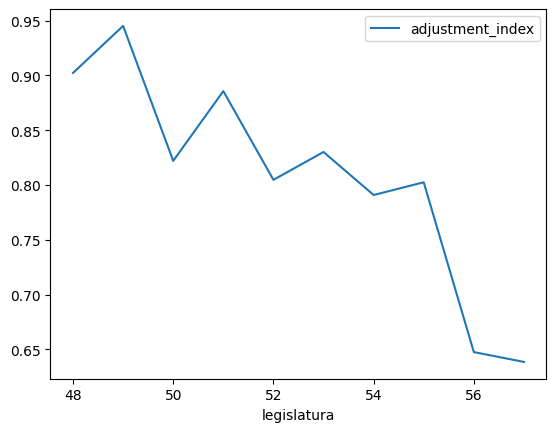

In [95]:
pd.DataFrame(results).plot(x='legislatura', y='adjustment_index', kind='line')


In [100]:
df_parls_raw[df_parls_raw['ultimoStatus.idLegislatura'] == 56].groupby('sexo').size()


sexo
F     52
M    243
dtype: int64